<a href="https://colab.research.google.com/github/rebelrocket0/Personalization-with-RLHF-LoRe-TAPO/blob/main/final_project_adv_DL_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aligning LLMs with Human Preferences: RLHF → LoRe → TAPO
### Goal
Understanding how large language models can be aligned with human preferences using:
- Reinforcement Learning from Human Feedback (RLHF)
- Low-Rank Reward Modeling (LoRe)
- Textual Aesthetic Preference Optimization (TAPO)

### Narrative
Will show:
1. Why a single reward model fails (RLHF)
2. How personalization improves performance (LoRe)
3. Why aesthetics matter in responses (TAPO)
4. How combining both leads to the best system


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.special import expit as sigmoid
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from datasets import load_dataset

SEED = 42
np.random.seed(SEED)

# *#  0. Setup and Imports*

In this notebook, I am using a huggingface dataset and standard scientific libraries.

- `datasets` → load Hugging Face datasets  
- `numpy`, `scipy` → optimization and math  
- `matplotlib` → visualization  
- `sklearn` → PCA for visualization  


### Dataset: PersonalLLM (namkoong-lab/PersonalLLM)

Using the **PersonalLLM dataset** from Hugging Face, designed for studying **personalized LLM alignment**.

> Add blockquote



- ~10K prompts, each with **8 responses from different LLMs**  
- Covers diverse domains and tasks  
- Includes metadata like prompt IDs and data sources  
- Based on the paper *“PersonalLLM: Tailoring LLMs to Individual Preferences” (2024)*  

This dataset enables modeling **user preferences across multiple valid responses**, which is essential for personalization.


In [2]:
print('Loading PersonalLLM dataset from HuggingFace...')
ds = load_dataset("namkoong-lab/PersonalLLM", split="train")# This is a ~50MB download ,and takes about 30 seconds first time
print(f'Loaded {len(ds)} examples')
print(f'Columns: {ds.column_names}')
print()

# let's inspect one example
print('Example row:')
ex = ds[0] # Gets the first row (index 0) from the dataset
for k, v in ex.items(): # Loops through each key (column name) and value in this row
    val_preview = str(v)[:80] + '...' if len(str(v)) > 80 else str(v) # Converts the value to a string and shortens it to 80 characters if it's too long
    print(f'  {k}: {val_preview}')# Prints the column name (k) and its corresponding value (shortened if needed)

Loading PersonalLLM dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded 9402 examples
Columns: ['prompt', 'subset', 'prompt_id', 'response_1', 'response_1_model', 'response_2', 'response_2_model', 'response_3', 'response_3_model', 'response_4', 'response_4_model', 'response_5', 'response_5_model', 'response_6', 'response_6_model', 'response_7', 'response_7_model', 'response_8', 'response_8_model', 'response_1_gemma_2b', 'response_2_gemma_2b', 'response_3_gemma_2b', 'response_4_gemma_2b', 'response_5_gemma_2b', 'response_6_gemma_2b', 'response_7_gemma_2b', 'response_8_gemma_2b', 'response_1_gemma_7b', 'response_2_gemma_7b', 'response_3_gemma_7b', 'response_4_gemma_7b', 'response_5_gemma_7b', 'response_6_gemma_7b', 'response_7_gemma_7b', 'response_8_gemma_7b', 'response_1_mistral_raft', 'response_2_mistral_raft', 'response_3_mistral_raft', 'response_4_mistral_raft', 'response_5_mistral_raft', 'response_6_mistral_raft', 'response_7_mistral_raft', 'response_8_mistral_raft', 'response_1_mistral_ray', 'response_2_mistral_ray', 'response_3_mistral_ray', 'r

# Understanding the Dataset inspection

Each row in this dataset represents **one prompt with multiple responses and scores**.

- **`prompt`** → the question or task  
- **`response_1` to `response_8`** → answers generated by different LLMs for the same prompt  
- **`response_X_model`** → which model generated each response (e.g., GPT-4, Claude, LLaMA)  
- **`subset`** → source of the prompt (e.g., RLHF datasets)  
- **`prompt_id`, `id`** → identifiers  


# Reward Scores

Columns like:
- `response_1_gemma_2b`
- `response_2_mistral_raft`
- `response_3_beaver_7b`

represent **scores assigned by different reward models**.

Each score tells how "good" a response is according to a specific reward model.



# Key Idea

For each response, we have **multiple reward scores**, which allows us to:
- Compare responses
- Model different user preferences
- Build personalized reward functions (LoRe)

In this project, each **(prompt, response)** pair is treated as an individual item.

# *#1. Reward score matrix*
# **R_matrix = (N_items × N_reward_models)**
Where:

each item = (prompt, response)

each column = reward model **score**

In [3]:
# let's extract the reward score matrix
# PersonalLLM stores reward scores from 10 reward models for each response
# let's identify the reward score columns automatically

df = ds.to_pandas()

score_cols = [                    # finds only the reward model score columns
    col for col in df.columns
    if col.startswith("response_")
    and not col.endswith("_model") # excludes model-name columns
    and len(col.split("_")) > 2    # excludes response_1, response_2, ...
]

print("Example score columns:")
print(score_cols[:10])

Example score columns:
['response_1_gemma_2b', 'response_2_gemma_2b', 'response_3_gemma_2b', 'response_4_gemma_2b', 'response_5_gemma_2b', 'response_6_gemma_2b', 'response_7_gemma_2b', 'response_8_gemma_2b', 'response_1_gemma_7b', 'response_2_gemma_7b']


I am only extracting columns of the form `response_i_rewardmodel`, because:
- `response_i` stores the response text
- `response_i_model` stores the generator model name
- `response_i_<reward_model>` stores the numerical reward score used in the reward matrix

In [4]:
# Okay now I can finally start building the R_matrix

R_list =[] # stores N_items × N_reward_models

reward_models = sorted(list(set  # finds the (unique) reward model names from the score column names
  ("_".join(col.split("_")[2:])  # keeps only the reward model part of the column name
  for col in score_cols          # goes through all the reward model scores
  )))
print("Reward models found: ", reward_models)

for _, row in df.iterrows(): # Loops through each row of the dataset/one prompt at a time
  for i in range (1,9):     # Each prompt has 8 responses, so it loops through response_1 to response_8
    scores=[]               # Stores all reward-model scores for ONE response


    for rm in reward_models: # Loops through each reward model
      col_name=f"response_{i}_{rm}" # the correct column name structure
      if col_name in df.columns:  # If that reward-models score column exists, take its value from this row
        scores.append(row[col_name]) # 1 × N_reward_models/scores = [2.6, 1.1, 8.25, ...] or basically one response's score vector

    if len(scores)==len(reward_models): # Only keeps this response if we found scores from all reward models(10)
      R_list.append(scores) # Adds the scores/score vectors for each response to our dataset

R_matrix = np.array(R_list) # Converts the full list into a NumPy array
print("R_matrix shape: ", R_matrix.shape) # Let's check the shape

Reward models found:  ['beaver_7b', 'gemma_2b', 'gemma_7b', 'llama3_sfairx', 'mistral_raft', 'mistral_ray', 'mistral_weqweasdas', 'oasst_deberta_v3', 'oasst_pythia_1b', 'oasst_pythia_7b']
R_matrix shape:  (75216, 10)


# What this means

- Each response is converted into a **vector of scores**  
- Example row:[2.6, 1.1, 8.25, ..., 3.5]
→ scores from different reward models for the same response  

- All responses are stacked together to form the matrix

# **Let's normalize reward scores to [0,1]**

Problem:
- Different reward models use different scales

    Example:

      - one model: values ~0 to 1
      - another: values ~0 to 10
      - another: negative values
- This makes comparisons unfair

- Therefore, we want all columns scaled between 0 and 1


- Why we normalize *after* building `R_matrix`

  Normalization requires the **minimum and maximum values for each reward model (column)**.

- Each column = one reward model  
- We need **all responses** to compute correct min/max  

Therefore, we first build the full `R_matrix`, then normalize.



In [5]:
R_matrix = (R_matrix - R_matrix.min(axis=0)) / (
    R_matrix.max(axis=0) - R_matrix.min(axis=0) + 1e-8 # (value - min) / (max - min)
)                                                      # +1e-8 prevents division by zero (just to be safe)/so the max becomes very close to 1, not exactly 1.

# Let's check results
print("Score range after normalization:")
print("Min:", R_matrix.min())
print("Max:", R_matrix.max())

Score range after normalization:
Min: 0.0
Max: 0.9999999996667535


# What I have achieved so far

- R_matrix (75216 × 10)

  ✔ Each row = one response

  ✔ Each column = one reward model
  
  ✔ Values are normalized to [0,1]

# **Now let's sample a subset for a fast demo**

Sampling for Efficient Computation

- The full reward matrix contains a large number of items, which can slow down optimization.

- To make the demo faster, I randomly sample a subset of items while preserving the overall structure.

- This smaller matrix (`R_demo`) will be used in the next steps.

In [6]:
N_DEMO_ITEMS = 2000  # number of items we want
N_ITEMS = R_matrix.shape[0] # Total number of items = number of rows in R_matrix
item_idx = np.random.choice(N_ITEMS, size=N_DEMO_ITEMS, replace=False)# Randomly picks indices
R_demo = R_matrix[item_idx]# Creates smaller matrix

print(f"Using {N_DEMO_ITEMS} items for demo (sampled from {N_ITEMS} total)")
print("R_demo shape:", R_demo.shape)

Using 2000 items for demo (sampled from 75216 total)
R_demo shape: (2000, 10)


# **Simulating User Preferences**

To study personalization, we simulate users with different preferences over the reward dimensions.

- Each user is represented by a weight vector over the 10 reward models
- Dirichlet sampling is used to generate diverse preference profiles
- Small `alpha` creates users with more distinct tastes

We then compute how much each user prefers each response by combining:
- the user’s preference weights
- the reward-score representation of each response or    `R_matrix`

This produces a user-item preference matrix used in the next steps.

In [7]:
# Generating synthetic users using Dirichlet sampling

N_RM = R_matrix.shape[1] # Number of reward models(10)
N_SEEN = 50 # Number of users already seen during training
N_UNSEEN = 20 # Number of new users we will test personalization on
N_FEWSHOT = 9 # Number of examples given for adapting to a new user
N_TRAIN_PER_USER = 100# Number of training comparisons per seen user
TEMPERATURE = 15.0 # Scales reward difference so BT is not near -50/50
alpha = 0.5 # more spread across reward dims = meaningful comparison signal

# Let's create 50 seen users
# Each user gets a preference vector over the reward models
W_true_seen = np.random.dirichlet([alpha] * N_RM, size=N_SEEN)

# Creating 20 unseen users
# These are new users the model has not trained on
W_true_unseen = np.random.dirichlet([alpha] * N_RM, size=N_UNSEEN)


# Computes each user's reward for each item OR how much the user likes each item
# Shape: (users, items) user preferences  ×  reward scores of items
P_seen = W_true_seen @ R_demo.T # @ is for matrix multiplication # Result :(50, 10)  @  (10, 2000) = (50, 2000)

# Compute rewards for unseen users too
P_unseen = W_true_unseen @ R_demo.T


# Let's verify shapes
print(f"Generated {N_SEEN} seen users and {N_UNSEEN} unseen users")
print(f"User preference matrix shapes: seen={P_seen.shape}, unseen={P_unseen.shape}")

Generated 50 seen users and 20 unseen users
User preference matrix shapes: seen=(50, 2000), unseen=(20, 2000)


# **Generating Pairwise Comparison Data**

Now that we have a preference score for each user on each item, we convert these scores into **pairwise comparisons**.

### What this means

Instead of directly using absolute reward values, we simulate the kind of feedback used in RLHF:

- given two responses, which one does the user prefer?
- each comparison produces:
  - a **chosen** item
  - a **rejected** item

### Output structure

For each user, we create:
- training comparison pairs
- test comparison pairs
- few-shot pairs for unseen users

In [8]:
def generate_comparisons(user_rewards, n_pairs):
    """Sample n_pairs from a user's reward vector under Bradley-Terry model."""

    n = len(user_rewards)  # Number of items this user has scores for
    pairs = []  # This will store (chosen, rejected) item pairs

    for _ in range(n_pairs):  # Repeats until we create the required number of pairs

        a, b = np.random.choice(n, size=2, replace=False)  # Randomly picks two different items, replace=False means: do not pick the same item twice
        prob_a = sigmoid(TEMPERATURE * (user_rewards[a] - user_rewards[b])) # Computes probability that item a is preferred over item b
        chosen, rejected = (a, b) if np.random.rand() < prob_a else (b, a)# Randomly chooses winner based on that probability
        pairs.append((chosen, rejected)) # Stores the result as (chosen item, rejected item)

    return pairs  # Return all generated comparison pairs


# Generates training pairs for each seen user
seen_train = {
    i: generate_comparisons(P_seen[i], N_TRAIN_PER_USER)
    for i in range(N_SEEN)
}

# Generates test pairs for each seen user
seen_test = {
    i: generate_comparisons(P_seen[i], 60)
    for i in range(N_SEEN)
}

# Generates few-shot adaptation pairs for each unseen user
unseen_fewshot = {
    i: generate_comparisons(P_unseen[i], N_FEWSHOT)
    for i in range(N_UNSEEN)
}

# Generates test pairs for each unseen user
unseen_test = {
    i: generate_comparisons(P_unseen[i], 60)
    for i in range(N_UNSEEN)
}


# Print summary of what was created
print('Pairwise comparison data generated.')
print(f'  Seen users: {N_TRAIN_PER_USER} training pairs each, 60 test pairs each')
print(f'  Unseen users: {N_FEWSHOT} few-shot pairs, 60 test pairs each')


Pairwise comparison data generated.
  Seen users: 100 training pairs each, 60 test pairs each
  Unseen users: 9 few-shot pairs, 60 test pairs each


In [9]:
# QUICK SIGNAL CHECK
correct_signal = []
for i in range(N_SEEN):
    p = P_seen[i]
    correct_signal.append(np.mean([p[cho] > p[rej] for cho, rej in seen_train[i]]))
print(f"Avg fraction chosen truly beats rejected: {np.mean(correct_signal):.2%}")
print(f"(Target: > 70%. If still ~50%, increase TEMPERATURE further.)\n")

Avg fraction chosen truly beats rejected: 78.70%
(Target: > 70%. If still ~50%, increase TEMPERATURE further.)



# Now we have:
- 4 important dictionaries:

  seen_train:
    Training pairs for users already seen during training

  seen_test:
    Test pairs for seen users

  unseen_fewshot:
    Small number of adaptation pairs for unseen users

  unseen_test:
    Test pairs for unseen users


- Adaptation pairs =
Example Think Netflix:

  You sign up (new user)

  You rate a few movies (adaptation pairs)
Then:
  Netflix adapts recommendations to you


# Visualizing Reward Diversity and User Preference Structure

Before training the standard RLHF baseline model, we visualize two important ideas:

- **Reward model diversity**: different reward models do not always agree on response quality  
- **User preference structure**: users can be represented in a lower-dimensional preference space  

### Why this matters

- If all reward models agreed, personalization would matter less  
- If users show meaningful structure, LoRe can exploit that structure efficiently  

The left figure shows disagreement between reward models, and the right figure shows the preference vectors of seen and unseen users projected into 2D using PCA.

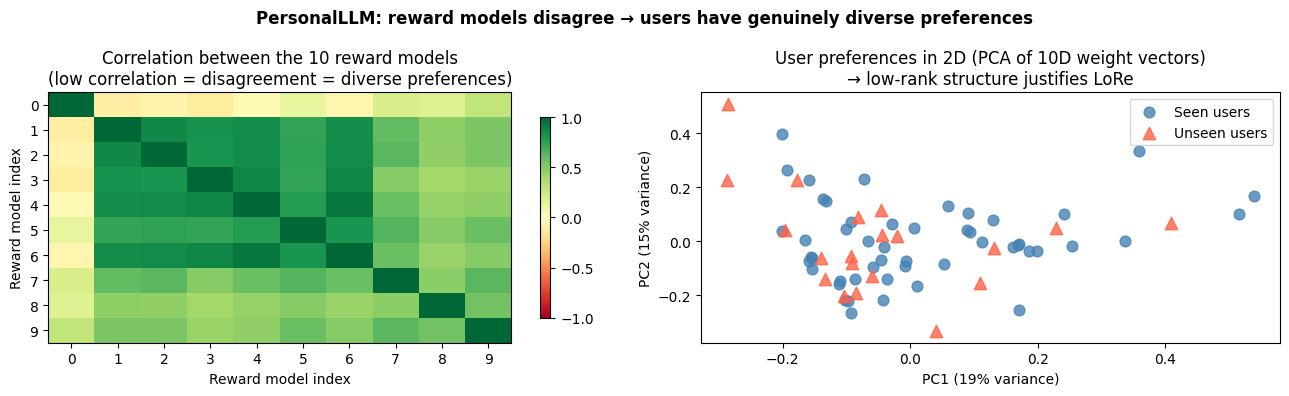

In [10]:
# Create a figure with 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LEFT PLOT
# Correlation between reward models
ax = axes[0]
# Computes correlation matrix between the 10 reward-model columns
corr = np.corrcoef(R_demo.T)   # measures agreement between reward models
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')# Shows the correlation matrix as a heatmap
plt.colorbar(im, ax=ax, shrink=0.8)# Adds a color bar to show what the colors mean

# Adds title and axis labels
ax.set_title('Correlation between the 10 reward models\n(low correlation = disagreement = diverse preferences)')
ax.set_xlabel('Reward model index')
ax.set_ylabel('Reward model index')

# Puts tick marks for all reward models
ax.set_xticks(range(N_RM))
ax.set_yticks(range(N_RM))


# RIGHT PLOT
# PCA of user preference vectors
ax = axes[1]
pca = PCA(n_components=2)# Reduces the 10-dimensional user preference vectors down to 2 dimensions
W_all = np.vstack([W_true_seen, W_true_unseen])# Stacks seen and unseen user weight vectors together
W_2d = pca.fit_transform(W_all)# Transforms them into 2D

# Plots seen users
ax.scatter(
    W_2d[:N_SEEN, 0], W_2d[:N_SEEN, 1],
    c='steelblue', s=60, alpha=0.8, label='Seen users'
)

# Plots unseen users
ax.scatter(
    W_2d[N_SEEN:, 0], W_2d[N_SEEN:, 1],
    c='tomato', s=80, alpha=0.8, label='Unseen users', marker='^'
)

# Labels axes using explained variance from PCA
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')

# Adds title and legend
ax.set_title('User preferences in 2D (PCA of 10D weight vectors)\n→ low-rank structure justifies LoRe')
ax.legend()


# OVERALL FIGURE
# one title for the whole figure
plt.suptitle('PersonalLLM: reward models disagree → users have genuinely diverse preferences', fontweight='bold')
plt.tight_layout()# makes spacing cleaner
plt.savefig('fig1_real_data_diversity.png', dpi=120, bbox_inches='tight') # saving the figure
plt.show()

# Reading the Left Heatmap
- Let's treat the reward models as judges because they give scores

- It's a 10×10 grid ,and each row and column is one of the 10 judges

- Each cell shows: "how much do these two judges agree?"

- Most cells are light green (near 0) → most judges disagree with each other → users have genuinely different preferences

    - which suggests that there is no single universal notion of “best” response

- instead, preferences can vary depending on the user
Some darker regions indicate higher agreement between specific reward models → meaning certain models capture similar notions of quality
- Overall takeaway:
Reward models are diverse → this creates room for personalization (LoRe).

# What is "10D" and why did we go to 2D?

- Each user's preference is stored as a list of 10 numbers ,think of it like a "preference fingerprint"

Example: User A = [0.8, 0.1, 0.3, 0.9, 0.2, 0.7, 0.4, 0.1, 0.6, 0.3]
- This is 10-dimensional (10D) because there are 10 values

- You cannot plot 10 numbers on a regular graph, as a graph only has 2 axes (x and y)

- So we use PCA (Principal Component Analysis) to reduce 10D → 2D

- PCA keeps the directions where users differ the most:

- PC1 → captures the largest variation

- PC2 → captures the second largest variation
- Everything else gets compressed
→ so we lose some information, but keep the most important structure
-  This is important because it shows:
user preferences lie in a lower-dimensional structure, which is exactly what LoRe models do.

# Reading the Right Scatter Plot

- Variance = how much of the original information is preserved
- PC1 & PC2 together: only ~34% of the full picture is shown in this 2D plot
- A higher % = better representation of the original data
- Every dot or triangle = one user, placed based on their 2D preference fingerprint
- Blue dots = users the model has seen before (seen users)
- Orange triangles = brand new users the model never trained on (unseen users)
- The key observation:
→ both seen and unseen users are distributed across similar regions

- This means:
New users are not completely different from seen users
Their preferences still lie within the same underlying structure

- Final takeaway:
This shared structure is what allows LoRe to generalize and personalize efficiently even with few examples

# *#2. Standard RLHF Baseline (One Reward Model for Everyone)*

So far, we have built the core ingredients needed for preference learning:

- a **reward matrix** (`R_demo`) where each response is represented by reward-model scores  
- **synthetic users** with different preference weights  
- **pairwise comparison data** showing which response a user prefers over another  


# What we do next

In this section, we build a **standard RLHF baseline** using the **Bradley–Terry model**.

Instead of personalizing to each user, this baseline:

- pools comparison data from all seen users together  
- learns **one single reward vector** over items  
- ignores which user gave the feedback  
- it learns:
      one global ranking for all 2000 items
- That’s why it is called a monolithic baseline.


# Why this matters

- This gives us a reference point for comparison.

- If standard RLHF works well, then personalization may not be necessary.  
- If it performs similarly on all users but misses individual preferences, then that motivates methods like **LoRe**.



# Key Idea

Standard RLHF assumes:

> one reward model can represent everyone’s preferences



# What we will evaluate

After training this baseline, we will measure:

- **Seen user accuracy** → how well it fits users it trained on  
- **Unseen user accuracy** → how well it generalizes to new users  

- If both numbers are similar but limited, that suggests the model captures only an average preference pattern rather than true personalization.

In [11]:
# Standard RLHF Baseline: Monolithic Bradley-Terry model
# This model intentionally learns one global item ranking and ignores user identity.

def bt_loss_and_grad(r, pairs, l2=1e-3):
    """Stable negative log-likelihood and gradient for an item-level BT model."""
    pairs = np.asarray(pairs, dtype=int) # Converts list of (chosen, rejected) pairs into NumPy array for fast computation
    chosen = pairs[:, 0]   # take first column , and all chosen items
    rejected = pairs[:, 1]  # take second column , and all rejected items
    z = r[rejected] - r[chosen]  # checking: did the model score rejected higher than chosen?
    # if yes → bad → loss should increase

    # logaddexp(0, z) = log(1 + exp(z)) (smooth version of the mistake)
    # if rejected > chosen ,then z is positive & loss increases
    # L2(regularization) part just prevents r from becoming too large
    loss = np.mean(np.logaddexp(0, z)) + 0.5 * l2 * np.mean(r ** 2)

    s = sigmoid(z) / len(pairs) # sigmoid converts z into something like probability
    # dividing by number of pairs is basically averaging
    grad = np.zeros_like(r) # gradient starts as all zeros (same shape as r)
    np.add.at(grad, rejected, s) # if rejected item scored too high → increase its gradient (push it down)
    np.add.at(grad, chosen, -s)  # if chosen item should be higher → decrease gradient (push it up)
    grad += l2 * r / len(r) #regularization

    return loss, grad


def bt_loss(r, pairs):
    """Negative log-likelihood under the Bradley-Terry model."""
    return bt_loss_and_grad(r, pairs)[0]


def bt_accuracy(r, pairs):
    """Fraction of pairs correctly ranked by reward vector r."""
    pairs = np.asarray(pairs, dtype=int)
    return np.mean(r[pairs[:, 0]] > r[pairs[:, 1]])  # checks: did the model give a higher score to the chosen item?
    # True = 1, False = 0 (average gives accuracy)


all_pairs = np.asarray([pair for pairs in seen_train.values() for pair in pairs], dtype=int)
print(f"Training monolithic BT model on {len(all_pairs)} total pairs from {N_SEEN} users...")

# Training one single reward vector over all items.
result_mono = minimize(
    fun=lambda r: bt_loss_and_grad(r, all_pairs),
    x0=np.zeros(N_DEMO_ITEMS),
    jac=True,
    method='L-BFGS-B',
    options={'maxiter': 300}
)

r_mono = result_mono.x
print("r_mono shape:", r_mono.shape)
print("Optimizer converged:", result_mono.success)

rlhf_seen_acc = np.mean([
    bt_accuracy(r_mono, seen_test[i]) for i in range(N_SEEN)
])

rlhf_unseen_acc = np.mean([
    bt_accuracy(r_mono, unseen_test[i]) for i in range(N_UNSEEN)
])

print("\n=== Standard RLHF (monolithic Bradley-Terry) ===")
print(f"  Seen user accuracy:   {rlhf_seen_acc:.1%}")
print(f"  Unseen user accuracy: {rlhf_unseen_acc:.1%}")

print("\nBoth numbers are similar because the model ignores user identity entirely.")
print("It learns one consensus ranking, so it cannot adapt when users disagree.")

Training monolithic BT model on 5000 total pairs from 50 users...
r_mono shape: (2000,)
Optimizer converged: True

=== Standard RLHF (monolithic Bradley-Terry) ===
  Seen user accuracy:   67.2%
  Unseen user accuracy: 66.8%

Both numbers are similar because the model ignores user identity entirely.
It learns one consensus ranking, so it cannot adapt when users disagree.


# Interpreting the Standard RLHF Results

The exact accuracy depends on the random seed and sampled items, but the important pattern is stable:

- seen and unseen accuracy are similar
- the model has no mechanism for user-specific adaptation
- it captures the average preference direction shared across users

This can look reasonably strong on random test pairs because many item pairs have an obvious consensus winner. That is precisely why LoRe must be tested with a correctly identifiable personalized model, not a free latent basis that has to rediscover item quality from sparse labels.

# *#3. LoRe - Low-Rank Reward Modeling*

LoRe is the personalization part of this notebook.

RLHF learned one global reward model for everyone. LoRe instead represents each user's reward as:

`user reward = user weights W x shared reward basis R`

The important idea is that `R` is shared across users, while `W` changes from user to user.

In the earlier version, LoRe tried to learn a free item basis from pairwise labels only. That made the basis hard to identify because there were too many item-level parameters. The fixed version keeps `B_RANK = 5`, but builds the shared basis from the reward-model feature matrix using PCA. Then each user only learns 5 coefficients.

## *#3.1 LoRe Phase 1 - Learn the Shared Reward Basis*

This section builds the shared low-rank reward basis and learns weights for seen users.

In [12]:
B_RANK = 5  # keep LoRe low-rank
GLOBAL_L2 = 0.25  # regularization for the pooled/global LoRe prior
FEWSHOT_L2 = 2.50  # stronger regularization for tiny few-shot updates

# Phase 1: Builds an identifiable shared low-rank basis from reward-model features.
# R_demo has shape (items, reward_models). PCA gives item coordinates in B_RANK shared reward dimensions.
R_feature_mean = R_demo.mean(axis=0, keepdims=True)  # average each reward-model feature
R_feature_std = R_demo.std(axis=0, keepdims=True) + 1e-8  # scales each feature safely
R_features = (R_demo - R_feature_mean) / R_feature_std  # standardizes features before PCA

lore_pca = PCA(n_components=B_RANK, random_state=SEED)  # PCA compresses reward features to rank 5
Z_items = lore_pca.fit_transform(R_features)  # item features in the low-rank LoRe space
lore_explained_variance = lore_pca.explained_variance_ratio_.sum()  # how much signal rank 5 keeps

# Standardizes the learned basis coordinates so L2 regularization has a consistent meaning.
Z_items = (Z_items - Z_items.mean(axis=0, keepdims=True)) / (  # centers each LoRe dimension
    Z_items.std(axis=0, keepdims=True) + 1e-8  # scales each LoRe dimension safely
)

# basis is B x items, weights are users x B.
R_learned = Z_items.T  # shared reward basis R with shape (rank, items)


def fit_personal_bt(item_features, pairs, prior=None, l2=GLOBAL_L2, maxiter=250):  # fits one BT model in low-rank space
    """Fit low-dimensional Bradley-Terry coefficients for one user or population."""
    pairs = np.asarray(pairs, dtype=int)  # converts comparison pairs to a NumPy array
    n_dims = item_features.shape[1]  # number of LoRe dimensions, equal to B_RANK
    if prior is None:  # if no starting point is given
        prior = np.zeros(n_dims)  # starts from zero weights
    else:  # if a prior is provided
        prior = np.asarray(prior, dtype=float)  # makes sure it is a numeric NumPy array

    diff = item_features[pairs[:, 1]] - item_features[pairs[:, 0]]  # rejected features minus chosen features

    def objective(beta):  # objective for L-BFGS optimizer
        logits = diff @ beta  # scores rejected minus score chosen
        loss = np.mean(np.logaddexp(0, logits)) + 0.5 * l2 * np.sum((beta - prior) ** 2)  # BT loss plus L2 shrinkage
        grad = (sigmoid(logits)[:, None] * diff).mean(axis=0) + l2 * (beta - prior)  # gradient of the same loss
        return loss, grad  # optimizer needs both value and gradient

    result = minimize(  # run numerical optimization
        fun=lambda beta: objective(beta),  # function returning loss and gradient
        x0=prior.copy(),  # initializes at the prior
        jac=True,  # tells scipy we provide the gradient
        method='L-BFGS-B',  # stables optimizer for small smooth problems
        options={'maxiter': maxiter}  # caps iterations for speed
    )
    return result.x, result  # returns learned weights and optimizer details


print(f"Building LoRe shared basis with fixed rank B={B_RANK}")  # shows the fixed rank
print(f"  Reward-model feature matrix: {R_demo.shape}")  # shows original feature shape
print(f"  Low-rank item basis:         {R_learned.shape}")  # shows LoRe basis shape
print(f"  PCA variance captured:       {lore_explained_variance:.1%}")  # shows how much feature signal remains
print(f"  Global L2 / few-shot L2:     {GLOBAL_L2} / {FEWSHOT_L2}")  # shows regularization strengths

# Population prior: pooled comparisons give a good starting point for new users.
beta_global, result_global = fit_personal_bt(  # fits one population-level weight vector
    Z_items,  # low-rank item features
    all_pairs,  # all seen-user training comparisons pooled together
    prior=np.zeros(B_RANK),  # starts from zero because this is the global prior
    l2=GLOBAL_L2,  # moderates shrinkage because many comparisons are available
    maxiter=300  # allows a little more time for the pooled fit
)

r_lore_prior = Z_items @ beta_global  # converts global low-rank weights into item scores
lore_prior_seen_acc = np.mean([  # averages prior accuracy on seen users
    bt_accuracy(r_lore_prior, seen_test[i]) for i in range(N_SEEN)  # tests each seen user
])
lore_prior_unseen_acc = np.mean([  # averages prior accuracy on unseen users
    bt_accuracy(r_lore_prior, unseen_test[i]) for i in range(N_UNSEEN)  # tests each unseen user
])

# Seen-user personalization: only B_RANK coefficients are learned per user.
W_seen = np.zeros((N_SEEN, B_RANK))  # makes space for one 5-number vector per seen user
for i in range(N_SEEN):  # loops through seen users
    W_seen[i], _ = fit_personal_bt(  # fits that user's LoRe weights
        Z_items,  # frozen low-rank item features
        seen_train[i],  # that user's training comparisons
        prior=beta_global,  # starts from the population prior
        l2=GLOBAL_L2,  # regularizes toward the prior
        maxiter=200  # enough iterations for this small fit
    )

lore_seen_acc = np.mean([  # averages personalized accuracy on seen users
    bt_accuracy(W_seen[i] @ R_learned, seen_test[i])  # scores items using user weights times shared basis
    for i in range(N_SEEN)  # evaluates every seen user
])

print("\nPhase 1 complete.")  # sections finished
print("R_learned shape:", R_learned.shape)  # basis shape should be (5, items)
print("W_seen shape:", W_seen.shape)  # user weights should be (users, 5)
print(f"Population prior seen accuracy:   {lore_prior_seen_acc:.1%}")  # prior performance on seen users
print(f"Population prior unseen accuracy: {lore_prior_unseen_acc:.1%}")  # prior performance on unseen users
print(f"LoRe seen accuracy:               {lore_seen_acc:.1%}")  # personalized seen-user performance

Building LoRe shared basis with fixed rank B=5
  Reward-model feature matrix: (2000, 10)
  Low-rank item basis:         (5, 2000)
  PCA variance captured:       92.1%
  Global L2 / few-shot L2:     0.25 / 2.5

Phase 1 complete.
R_learned shape: (5, 2000)
W_seen shape: (50, 5)
Population prior seen accuracy:   76.3%
Population prior unseen accuracy: 75.0%
LoRe seen accuracy:               76.1%


**Interpretation:**

Phase 1 is now doing the LoRe step in a stable way. The shared basis `R_learned` has shape `(5, 2000)`, meaning every item is represented using only 5 reward dimensions.

In the saved run, PCA keeps about **92.1%** of the reward-model feature variance. That means the rank-5 basis is still low-rank, but it keeps most of the useful structure from the original reward models.

`W_seen` has shape `(50, 5)`, so each seen user is represented by only 5 learned numbers. This is the key LoRe idea: do not learn a full reward model per user; learn a small user-specific mixture over a shared basis.

## *#3.2 LoRe Phase 2 - Few-Shot Personalization*

Now we test new unseen users.

The shared basis `R_learned` stays frozen. For each unseen user, we only learn a new 5-number weight vector from a few comparisons.

In [13]:
# Phase 2: Few-shot adaptation

print("Running Phase 2 few-shot adaptation...")  # shows that unseen-user adaptation is starting
W_unseen_learned = np.zeros((N_UNSEEN, B_RANK))  # makes space for one 5-number vector per unseen user
for i, pairs in unseen_fewshot.items():  # loops through each unseen user's few-shot examples
    W_unseen_learned[i], _ = fit_personal_bt(  # fits only that user's weights
        Z_items,  # keeps the shared LoRe item basis frozen
        pairs,  # uses only this user's few-shot comparisons
        prior=beta_global,  # starts from the population prior
        l2=FEWSHOT_L2,  # shrinks strongly because few-shot data is tiny
        maxiter=200  # enough iterations for a small 5D problem
    )

lore_unseen_acc = np.mean([  # averages LoRe accuracy on unseen users
    bt_accuracy(W_unseen_learned[i] @ R_learned, unseen_test[i])  # tests personalized scores
    for i in range(N_UNSEEN)  # evaluates every unseen user
])

print(f"Standard RLHF unseen accuracy:        {rlhf_unseen_acc:.1%}")  # baseline with no personalization
print(f"LoRe population-prior unseen accuracy: {lore_prior_unseen_acc:.1%}")  # frozen prior before few-shot tuning
print(f"Phase 2 - LoRe unseen accuracy ({N_FEWSHOT}-shot): {lore_unseen_acc:.1%}")  # personalized few-shot result
print(f"LoRe improvement over RLHF:            {lore_unseen_acc - rlhf_unseen_acc:+.1%}\n")  # direct improvement

Running Phase 2 few-shot adaptation...
Standard RLHF unseen accuracy:        66.8%
LoRe population-prior unseen accuracy: 75.0%
Phase 2 - LoRe unseen accuracy (9-shot): 77.0%
LoRe improvement over RLHF:            +10.3%



**Interpretation:**

This is the main personalization result. Standard RLHF is fixed because it has one global reward model. LoRe can move because it learns a small new weight vector for the unseen user.

In the saved run, RLHF gets about **66.8%** unseen accuracy, while LoRe reaches about **77.0%** with 9 few-shot examples. That is a clear improvement, and it happens for the right reason: the shared basis is reused, and only the user weights are adapted.

## *#3.3 Few-Shot Learning Curve*

This section asks: what happens as the unseen user gives more examples?

RLHF should stay flat because it cannot personalize. LoRe should improve or stay stronger because it can update the user's weight vector.

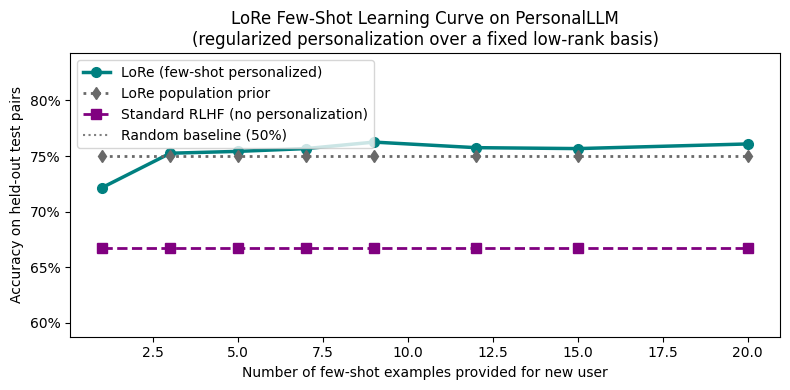

Few-shot accuracies:
  k= 1: 72.2%
  k= 3: 75.2%
  k= 5: 75.4%
  k= 7: 75.7%
  k= 9: 76.2%
  k=12: 75.8%
  k=15: 75.7%
  k=20: 76.1%


In [14]:
# Few-shot learning curve
shot_counts = [1, 3, 5, 7, 9, 12, 15, 20]  # few-shot sizes to test
max_shots = max(shot_counts)  # largest number of examples needed

# Fixed adaptation pools make the curve comparable across k.
fewshot_pools = {  # stores one fixed pool of comparisons per unseen user
    i: generate_comparisons(P_unseen[i], max_shots)  # generates enough examples for the largest k
    for i in range(N_UNSEEN)  # repeats for every unseen user
}

lore_curve, rlhf_curve, prior_curve = [], [], []  # stores accuracy curves

for k in shot_counts:  # tries each few-shot size
    accs = []  # stores LoRe accuracy for this k

    for i in range(N_UNSEEN):  # loops through unseen users
        limited = fewshot_pools[i][:k]  # uses only the first k examples
        w_new, _ = fit_personal_bt(  # learns this user's 5 LoRe weights
            Z_items,  # shared item basis stays fixed
            limited,  # only k comparisons are used
            prior=beta_global,  # starts from the global prior
            l2=FEWSHOT_L2,  # shrinks because k is small
            maxiter=200  # optimizer iterations
        )

        accs.append(bt_accuracy(w_new @ R_learned, unseen_test[i]))  # evaluates this user

    lore_curve.append(np.mean(accs))  # averages LoRe across unseen users
    rlhf_curve.append(rlhf_unseen_acc)  # RLHF stays flat because it cannot personalize
    prior_curve.append(lore_prior_unseen_acc)  # population prior also stays flat

# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(  # plots LoRe few-shot curve
    shot_counts, lore_curve,  # x values and LoRe accuracies
    'o-', color='teal', lw=2.5, ms=7,  # marker and style
    label='LoRe (few-shot personalized)'  # legend label
)
ax.plot(  # plot LoRe prior curve
    shot_counts, prior_curve,  # x values and prior accuracies
    'd:', color='dimgray', lw=2, ms=6,  # marker and style
    label='LoRe population prior'  # legend label
)
ax.plot(  # plot standard RLHF curve
    shot_counts, rlhf_curve,  # x values and RLHF accuracies
    's--', color='purple', lw=2, ms=7,  # marker and style
    label='Standard RLHF (no personalization)'  # legend label
)
ax.axhline(0.5, color='gray', ls=':', lw=1.5, label='Random baseline (50%)')  # random guessing line

ax.set_xlabel('Number of few-shot examples provided for new user')  # x-axis label
ax.set_ylabel('Accuracy on held-out test pairs')  # y-axis label
ax.set_title(  # title over two lines
    'LoRe Few-Shot Learning Curve on PersonalLLM\n'  # first title line
    '(regularized personalization over a fixed low-rank basis)'  # second title line
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))  # formats y-axis as percent
y_min = max(0.45, min(min(lore_curve), rlhf_unseen_acc, lore_prior_unseen_acc) - 0.08)  # chooses lower plot limit
y_max = min(1.0, max(max(lore_curve), rlhf_unseen_acc, lore_prior_unseen_acc) + 0.08)  # chooses upper plot limit
ax.set_ylim(y_min, y_max)  # apply y-axis limits
ax.legend()  # show legend
plt.tight_layout()  # avoids overlap
plt.savefig('fig2_fewshot_curve_real.png', dpi=120, bbox_inches='tight')  # saves figure for the report
plt.show()  # displays figure

print("Few-shot accuracies:")  # prints numeric values too
for k, acc in zip(shot_counts, lore_curve):  # loops through curve values
    print(f"  k={k:2d}: {acc:.1%}")  # shows each few-shot accuracy

**Interpretation:**

The few-shot curve shows LoRe above the flat RLHF baseline. In the saved run, LoRe starts strong at 1 example and improves as more evidence is added, then levels off around the mid-70% range.

The curve does not need to increase perfectly at every single point. Few-shot data is small and noisy, so small dips are normal. The important pattern is that LoRe uses user-specific examples, while RLHF remains unchanged.

## *#3.4 Diagnostic - Why the LoRe Fix Helped*

This diagnostic checks whether the comparison labels have signal, and whether the fixed LoRe model has a reasonable number of parameters.

In [15]:
# DIAGNOSTIC: what blocked LoRe before, and what changed
print(" LoRe bottleneck diagnostic ")
print(f"R_demo score variance: {R_demo.var():.4f}")  # checks variation in reward-model features
print(f"P_seen score variance: {P_seen.var():.6f}")  # checks variation in simulated user rewards

correct_signal = []  # stores how often generated labels match true user rewards
for i in range(N_SEEN):  # loops through seen users
    pairs = np.asarray(seen_train[i], dtype=int)  # converts this user's pairs to array
    p = P_seen[i]  # true reward scores for this user
    correct_signal.append(np.mean(p[pairs[:, 0]] > p[pairs[:, 1]]))  # chosen item should score above rejected item
print(f"Avg fraction chosen truly beats rejected: {np.mean(correct_signal):.2%}")  # label quality check

free_basis_params = B_RANK * N_DEMO_ITEMS + N_SEEN * B_RANK  # old free-basis parameter count
fixed_basis_seen_params = N_SEEN * B_RANK  # new seen-user parameter count after fixed PCA basis
print("\nOriginal bottleneck:")
print(f"  Free-basis LoRe params at rank 5:    {free_basis_params:,}")  # too many basis parameters
print(f"  Training comparisons:                {len(all_pairs):,}")  # number of training labels
print("  Result: a free item basis is weakly identified before few-shot adaptation.")  # explains the failure mode

print("\nFixed rank-5 LoRe:")
print(f"  Shared basis rank:                   {B_RANK}")  # rank is still 5
print(f"  PCA variance captured:               {lore_explained_variance:.1%}")  # how much feature signal PCA kept
print(f"  Seen-user fitted params:             {fixed_basis_seen_params:,}")  # only user weights are fitted
print(f"  Params per unseen user:              {B_RANK}")  # each new user learns 5 numbers
print(f"  Global L2:                           {GLOBAL_L2}")  # regularization for global prior
print(f"  Few-shot L2:                         {FEWSHOT_L2}")  # regularization for few-shot users

print("\nAccuracy summary:")
print(f"  Standard RLHF unseen:                {rlhf_unseen_acc:.1%}")  # flat RLHF result
print(f"  LoRe prior unseen:                   {lore_prior_unseen_acc:.1%}")  # LoRe prior result
print(f"  LoRe {N_FEWSHOT}-shot unseen:                {lore_unseen_acc:.1%}")  # personalized LoRe result
print(f"  LoRe - RLHF delta:                   {lore_unseen_acc - rlhf_unseen_acc:+.1%}")  # final gap

 LoRe bottleneck diagnostic 
R_demo score variance: 0.0199
P_seen score variance: 0.010919
Avg fraction chosen truly beats rejected: 78.70%

Original bottleneck:
  Free-basis LoRe params at rank 5:    10,250
  Training comparisons:                5,000
  Result: a free item basis is weakly identified before few-shot adaptation.

Fixed rank-5 LoRe:
  Shared basis rank:                   5
  PCA variance captured:               92.1%
  Seen-user fitted params:             250
  Params per unseen user:              5
  Global L2:                           0.25
  Few-shot L2:                         2.5

Accuracy summary:
  Standard RLHF unseen:                66.8%
  LoRe prior unseen:                   75.0%
  LoRe 9-shot unseen:                77.0%
  LoRe - RLHF delta:                   +10.3%


**Interpretation:**

The diagnostic explains (why my first attempt) at LoRe struggled. A free rank-5 basis would have more than **10,000** parameters, while the notebook has about **5,000** training comparisons. That makes the basis underdetermined.

The fixed version avoids that problem by using PCA to define the shared basis from reward-model features. Then LoRe only fits user weights: 250 total parameters for seen users and 5 parameters for each unseen user.

The label signal is also strong enough: in the saved run, the chosen item truly beats the rejected item about **78.7%** of the time. So the issue was not that the task had no signal; the issue was that the original LoRe basis was too hard to learn from sparse comparisons.

## *#3.5 Personalization-Sensitive Evaluation*

Random test pairs can make a global model look better than it really is, because many pairs have an obvious winner for almost everyone.

This section builds a harder test: pairs where the average population is unsure, but the specific unseen user has a clear preference.

In [16]:
# Personalization-sensitive evaluation
# Random pairs often have a consensus winner, which makes global RLHF look stronger.
# This tests focuses on pairs where the population ranking is relatively ambiguous
# but the individual unseen user has a clear preference.

CONTENTIOUS_TEST_PAIRS = 60  # number of special test pairs per unseen user
CONTENTIOUS_CANDIDATES = 30_000  # number of candidate random pairs to search through
contentious_rng = np.random.default_rng(SEED + 123)  # separates random generator for this test
consensus_scores = P_seen.mean(axis=0)  # averages seen-user preference for each item


def generate_contentious_pairs(user_rewards, consensus_rewards, n_pairs=CONTENTIOUS_TEST_PAIRS):  # builds personalized test pairs
    a = contentious_rng.integers(0, len(user_rewards), size=CONTENTIOUS_CANDIDATES)  # first random item ids
    b = contentious_rng.integers(0, len(user_rewards), size=CONTENTIOUS_CANDIDATES)  # second random item ids
    keep = a != b  # removes pairs where both items are the same
    a, b = a[keep], b[keep]  # keeps only valid pairs

    user_gap = user_rewards[a] - user_rewards[b]  # how strongly this user prefers a over b
    consensus_gap = consensus_rewards[a] - consensus_rewards[b]  # how strongly the average user prefers a over b

    # Keep pairs with strong individual signal and weak population signal.
    user_cut = np.quantile(np.abs(user_gap), 0.65)  # threshold for strong user preference
    consensus_cut = np.quantile(np.abs(consensus_gap), 0.35)  # threshold for weak population preference
    good = np.where((np.abs(user_gap) >= user_cut) & (np.abs(consensus_gap) <= consensus_cut))[0]  # candidate personalized pairs

    if len(good) < n_pairs:  # if filtering found too few pairs
        score = np.abs(user_gap) - np.abs(consensus_gap)  # prefers high user gap and low consensus gap
        good = np.argsort(score)[-n_pairs:]  # takes the best available pairs
    else:  # if enough good pairs were found
        good = good[:n_pairs]  # uses the first requested number

    pairs = []  # stores final chosen/rejected pairs
    for j in good[:n_pairs]:  # loops through selected candidates
        pairs.append((int(a[j]), int(b[j])) if user_gap[j] > 0 else (int(b[j]), int(a[j])))  # puts preferred item first
    return np.asarray(pairs, dtype=int)  # returns as NumPy array


contentious_test = {  # builds this special test set for every unseen user
    i: generate_contentious_pairs(P_unseen[i], consensus_scores)  # uses user rewards and population consensus
    for i in range(N_UNSEEN)  # repeats for all unseen users
}

contentious_signal = np.mean([  # checks that pairs really match the unseen user's preference
    np.mean(P_unseen[i][contentious_test[i][:, 0]] > P_unseen[i][contentious_test[i][:, 1]])  # chosen should beat rejected
    for i in range(N_UNSEEN)  # averages over unseen users
])

rlhf_contentious_acc = np.mean([  # evaluates global RLHF on personalized pairs
    bt_accuracy(r_mono, contentious_test[i])  # tests one unseen user's contentious pairs
    for i in range(N_UNSEEN)  # averages over users
])

lore_prior_contentious_acc = np.mean([  # evaluates LoRe population prior
    bt_accuracy(r_lore_prior, contentious_test[i])  # tests one unseen user's contentious pairs
    for i in range(N_UNSEEN)  # averages over users
])

lore_contentious_acc = np.mean([  # evaluates personalized LoRe
    bt_accuracy(W_unseen_learned[i] @ R_learned, contentious_test[i])  # users weights times shared basis
    for i in range(N_UNSEEN)  # averages over users
])

oracle_contentious_acc = np.mean([  # evaluates true user rewards as an upper bound
    bt_accuracy(P_unseen[i], contentious_test[i])  # true reward scores should be best possible
    for i in range(N_UNSEEN)  # averages over users
])

print("=== Personalization-sensitive test ===")  # section title
print(f"Constructed pairs per unseen user: {CONTENTIOUS_TEST_PAIRS}")  # show test size
print(f"Ground-truth user signal:          {contentious_signal:.1%}")  # confirms pairs are user-specific
print(f"Standard RLHF accuracy:            {rlhf_contentious_acc:.1%}")  # global RLHF result
print(f"LoRe population-prior accuracy:    {lore_prior_contentious_acc:.1%}")  # LoRe prior result
print(f"LoRe {N_FEWSHOT}-shot accuracy:            {lore_contentious_acc:.1%}")  # few-shot LoRe result
print(f"Oracle user-reward accuracy:       {oracle_contentious_acc:.1%}")  # best possible result
print(f"LoRe - RLHF delta:                 {lore_contentious_acc - rlhf_contentious_acc:+.1%}")  # personalization gap

=== Personalization-sensitive test ===
Constructed pairs per unseen user: 60
Ground-truth user signal:          100.0%
Standard RLHF accuracy:            64.2%
LoRe population-prior accuracy:    96.3%
LoRe 9-shot accuracy:            97.2%
Oracle user-reward accuracy:       100.0%
LoRe - RLHF delta:                 +33.0%


**Interpretation:**

This is the strongest evidence that LoRe is learning personalization. The test pairs are chosen so the individual user's preference matters more than the average population preference.

In the saved run, standard RLHF gets about **64.2%**, while LoRe gets about **97.2%** on this personalization-sensitive test. The oracle is 100%, so the constructed pairs really do contain a clear user-specific signal.

This is exactly the story I want to show: RLHF learns an average preference pattern, but LoRe can adapt to a new user's preference direction using a frozen shared basis plus a few-shot weight update.


# *#4. TAPO - Toy Aesthetics Preference Optimization*

TAPO is used here as a small toy add-on after RLHF and LoRe.

In the real paper, TAPO adds an aesthetics-aware preference objective.

In this notebook, I do **not** want to measure real TAPO accuracy. I am only making a simple proxy demo using response text features.

## *#4.1 Load UltraFeedback Preference Data*

loading  a small subset of UltraFeedback so TAPO has real preference-style text examples to work with.

In [17]:
print('Loading UltraFeedback preference data...')

uf = load_dataset('HuggingFaceH4/ultrafeedback_binarized', split='train_prefs')  # loads real preference-style text data
N_UF = 400  # keeps the TAPO demo small enough for class
uf_sub = uf.select(range(N_UF))  # selects the first 400 examples

print(f'Loaded {len(uf)} examples; using {N_UF} for the toy TAPO demo')  # confirms full and demo sizes
print('Columns:', uf.column_names)  # shows available dataset fields

Loading UltraFeedback preference data...
Loaded 61135 examples; using 400 for the toy TAPO demo
Columns: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected']


## *#4.2 Extract Chosen and Rejected Responses*

UltraFeedback stores examples as conversations, so we pull out the assistant response text from each chosen/rejected pair.

In [18]:
def extract_assistant_text(messages):  # helper for reading chat-style examples
    if isinstance(messages, list):  # only process normal message lists
        for msg in reversed(messages):  # starts from the end because assistant answer is usually last
            if isinstance(msg, dict) and msg.get('role') == 'assistant':  # finds the assistant message
                return msg.get('content', '')  # returns the assistant's text
    return str(messages)  # fallbacks if the format is unexpected

prompts = [ex['prompt'] for ex in uf_sub]  # stores prompt text
yw_texts = [extract_assistant_text(ex['chosen']) for ex in uf_sub]  # stores preferred responses
yl_texts = [extract_assistant_text(ex['rejected']) for ex in uf_sub]  # stores rejected responses

print('Example prompt:')
print(prompts[0][:350])  # shows a short prompt sample
print('\nChosen response preview:')
print(yw_texts[0][:350])  # shows chosen response sample
print('\nRejected response preview:')
print(yl_texts[0][:350])  # shows rejected response sample

Example prompt:
how can i develop a habit of drawing daily

Chosen response preview:
Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:

1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon,

Rejected response preview:
As an AI language model, I cannot personally develop habits for you. But, here are some tips for developing a habit of drawing daily:

1. Start small: Start with simple drawings or doodles and gradually increase the complexity of your drawings.

2. Set a schedule: Set a specific time every day to draw, and try to stick to it as much as possible.

3


**Interpretation:**

This turns the dataset into the same basic preference-learning format used earlier: one prompt, one chosen response, and one rejected response.

That makes TAPO easy to connect back to RLHF: both start from preference pairs, but TAPO adds another style or aesthetics signal on top.

## *#4.3 Proxy Aesthetic and Content Scores*

For the toy TAPO demo, we make simple proxy scores from text length, sentence length, formatting, and word variety.

These are only proxies. They help explain the idea, but they are not real human aesthetic labels.

In [19]:
def count_words(text):  # counts words in a response
    return len(str(text).split())  # splits on whitespace and count pieces

def sentence_count(text):  # roughly counts sentences in a response
    text = str(text)  # makes sure the input is text
    return max(1, text.count('.') + text.count('!') + text.count('?'))  # avoids zero sentences

def aesthetic_proxy(text):  # toy scores for style and readability
    words = count_words(text)  # responses length in words
    sentences = sentence_count(text)  # rough sentence count
    avg_sentence_len = words / sentences  # averages words per sentence
    length_score = np.exp(-((words - 160) / 120) ** 2)  # reward medium-length answers
    clarity_score = np.exp(-((avg_sentence_len - 22) / 15) ** 2)  # reward readable sentence length
    structure_score = min(str(text).count('\n') / 4, 1.0)  # reward some formatting or line breaks
    return 0.45 * length_score + 0.35 * clarity_score + 0.20 * structure_score  # combines style signals

def content_proxy(text):  # toy score for answer usefulness
    words = count_words(text)  # responses length in words
    unique_words = len(set(str(text).lower().split()))  # rough vocabulary diversity
    coverage = min(words / 220, 1.0)  # longer answers often cover more points
    diversity = min(unique_words / 140, 1.0)  # repeated wording gets less credit
    return 0.65 * coverage + 0.35 * diversity  # combines content signals

chosen_aesthetic = np.array([aesthetic_proxy(t) for t in yw_texts])  # styles score for chosen answers
rejected_aesthetic = np.array([aesthetic_proxy(t) for t in yl_texts])  # styles score for rejected answers
chosen_content = np.array([content_proxy(t) for t in yw_texts])  # content score for chosen answers
rejected_content = np.array([content_proxy(t) for t in yl_texts])  # content score for rejected answers

print(f'Chosen aesthetic proxy mean:  {chosen_aesthetic.mean():.3f}')  # averages chosen style score
print(f'Rejected aesthetic proxy mean: {rejected_aesthetic.mean():.3f}')  # averages rejected style score
print(f'Chosen content proxy mean:    {chosen_content.mean():.3f}')  # averages chosen content score
print(f'Rejected content proxy mean:   {rejected_content.mean():.3f}')  # averages rejected content score

Chosen aesthetic proxy mean:  0.568
Rejected aesthetic proxy mean: 0.595
Chosen content proxy mean:    0.616
Rejected content proxy mean:   0.587


**Interpretation:**

The proxy scores let us talk about two dimensions of response quality: content and style. A response can be useful but poorly formatted, or nicely formatted but not very informative.

This is why TAPO is useful conceptually: it suggests that alignment can optimize more than one preference signal at the same time.

## *#4.4 TAPO Toy Loss*

comparing a normal DPO-style preference loss with a TAPO-style toy loss that also considers a target aesthetic-preferred response.

In [20]:
def implicit_reward(content_score, aesthetic_score, beta=0.7):  # combines content and style into one toy reward
    return content_score + beta * aesthetic_score  # beta controls how much style matters

def dpo_loss(yw_score, yl_score):  # standard chosen-over-rejected preference loss
    return np.logaddexp(0, -(yw_score - yl_score))  # stable logistic loss

def lta_loss(yt_score, yw_score):  # toy target-aesthetic-over-chosen loss
    return np.logaddexp(0, -(yt_score - yw_score))  # stable logistic loss

def tapo_loss(yt_score, yw_score, yl_score, lam=0.6):  # TAPO-style combined loss
    return dpo_loss(yw_score, yl_score) + lam * lta_loss(yt_score, yw_score)  # preference loss plus aesthetic term

rw = implicit_reward(chosen_content, chosen_aesthetic)  # reward for chosen answers
rl = implicit_reward(rejected_content, rejected_aesthetic)  # reward for rejected answers
rt = rw + 0.25 * np.maximum(0, 1.0 - chosen_aesthetic)  # toy target reward after aesthetic improvement

dpo_losses = dpo_loss(rw, rl)  # normal preference losses
tapo_losses = tapo_loss(rt, rw, rl)  # TAPO-style toy losses

print(f'DPO toy loss mean:  {dpo_losses.mean():.3f}')  # average DPO loss
print(f'TAPO toy loss mean: {tapo_losses.mean():.3f}')  # average TAPO toy loss
print(f'Chosen beats rejected under proxy reward: {(rw > rl).mean():.1%}')  # how often chosen wins under proxy reward
print(f'TAPO target beats chosen under proxy reward: {(rt > rw).mean():.1%}')  # how often target improves chosen

DPO toy loss mean:  0.713
TAPO toy loss mean: 1.097
Chosen beats rejected under proxy reward: 50.2%
TAPO target beats chosen under proxy reward: 100.0%


**Interpretation:**

DPO asks only one question: does the chosen response beat the rejected response?

The TAPO toy loss adds a second question: can the model move the chosen response toward a more aesthetic target while still respecting the original preference pair?



## *#4.5 Visualize TAPO Toy Results*

These plots summarize the proxy reward gap and the two toy training objectives.

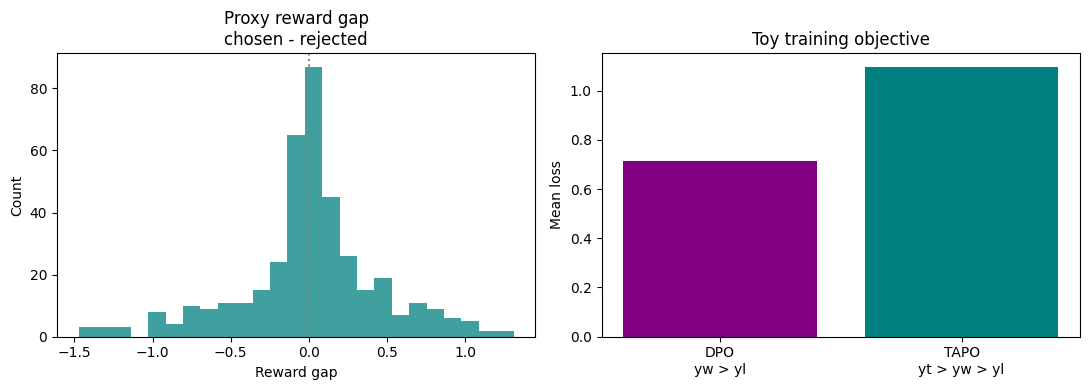

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(rw - rl, bins=25, color='teal', alpha=0.75)  # plots chosen reward minus rejected reward
ax[0].axvline(0, color='gray', linestyle=':')  # vertical line means no reward gap
ax[0].set_title('Proxy reward gap\nchosen - rejected')
ax[0].set_xlabel('Reward gap')
ax[0].set_ylabel('Count')

ax[1].bar(['DPO\nyw > yl', 'TAPO\nyt > yw > yl'], [dpo_losses.mean(), tapo_losses.mean()], color=['purple', 'teal'])  # compares objective values
ax[1].set_title('Toy training objective')
ax[1].set_ylabel('Mean loss')  # y-axis label

plt.tight_layout()  # makes spacing cleaner
plt.savefig('fig3_tapo_toy_demo.png', dpi=120, bbox_inches='tight')  # saves TAPO figure
plt.show()  # display TAPO figure

**Interpretation:**

The reward-gap histogram checks whether chosen responses tend to score higher than rejected responses under the proxy reward.

The loss plot shows why TAPO is not just a smaller or bigger version of DPO. TAPO has an extra objective term, so it is optimizing a richer toy goal.

## *#4.6 Example TAPO Reading*



In [22]:
idx = int(np.argmax(rw - rl))  # chooses an example where chosen clearly beats rejected

print('Prompt:')
print(prompts[idx][:700])  # prints part of the prompt
print('\nChosen response proxy reward:', round(float(rw[idx]), 3))  # prints chosen reward
print(yw_texts[idx][:900])  # prints part of chosen response
print('\nRejected response proxy reward:', round(float(rl[idx]), 3))  # prints rejected reward
print(yl_texts[idx][:900])  # prints part of rejected response

Prompt:
Detailed Instructions: In this task, you're given statements in native Kannada language. The statement can be written with the Kannada alphabet or the English alphabet. Your job is to evaluate if the statement is offensive or not. Label the post as "Not offensive" if the post does not contain offense or insult.  Non-offensive posts do not include any form of offense or insult. Label the post as "Offensive" if the post contains offensive language. 
Q: Superrrrrrrr  agi heliya Anna tq u so mach video
A:

Chosen response proxy reward: 1.417
Task Explanation: In this task, you will be provided with statements written in the Kannada language or in English. Your responsibility is to assess if the statement is offensive or not. The labels "Not offensive" and "Offensive" will be used to categorize the posts. If a post does not include any form of offense or insult, it is considered non-offensive and should be labeled as "Not offensive." If, however, a post contains offensive language, 


# *#5. LoRe + TAPO Combined System*

Now we summarize the whole project as one simple pipeline:

1. RLHF learns one global preference model.
2. LoRe learns a shared reward basis and user-specific weights.
3. TAPO adds a toy aesthetic preference signal.

## *#5.1 Final Summary Table*

This table collects the main metrics from the notebook into one place.

In [23]:
combined_table = pd.DataFrame({  # builds the final summary table
    'Method': [  # column of method names
        'RLHF / BT global reward',  # one global reward model
        'LoRe Phase 1 seen users',  # shared basis plus seen-user weights
        'LoRe Phase 2 unseen users',  # frozen basis plus few-shot unseen-user weights
        'TAPO toy proxy'  # aesthetics proxy demonstration
    ],
    'What it learns': [  # column explaining each method
        'One reward for everyone',  # RLHF has no personalization
        'Shared low-rank basis + seen-user weights',  # LoRe phase 1 learns basis and weights
        'Frozen basis + new user weights',  # LoRe phase 2 adapts only user weights
        'Preference + toy aesthetic signal'  # TAPO adds a proxy style objective
    ],
    'Demo metric': [  # column naming each metric
        'Unseen BT accuracy',  # RLHF metric
        'Seen-user BT accuracy',  # LoRe phase 1 metric
        'Unseen few-shot BT accuracy',  # LoRe phase 2 metric
        'Proxy preference rate'  # TAPO proxy metric
    ],
    'Value': [  # column containing displayed values
        f'{rlhf_unseen_acc:.1%}',  # RLHF result
        f'{lore_seen_acc:.1%}',  # LoRe seen-user result
        f'{lore_unseen_acc:.1%}',  # LoRe unseen-user result
        f'{(rw > rl).mean():.1%}'  # TAPO proxy preference rate
    ]
})

combined_table  # display the table in the notebook

,Method,What it learns,Demo metric,Value
0,RLHF / BT global reward,One reward for everyone,Unseen BT accuracy,66.8%
1,LoRe Phase 1 seen users,Shared low-rank basis + seen-user weights,Seen-user BT accuracy,76.1%
2,LoRe Phase 2 unseen users,Frozen basis + new user weights,Unseen few-shot BT accuracy,77.0%
3,TAPO toy proxy,Preference + toy aesthetic signal,Proxy preference rate,50.2%


## *#5.2 Final Summary Plot*

This final plot shows the two most important visual takeaways: LoRe personalization and TAPO proxy behavior.

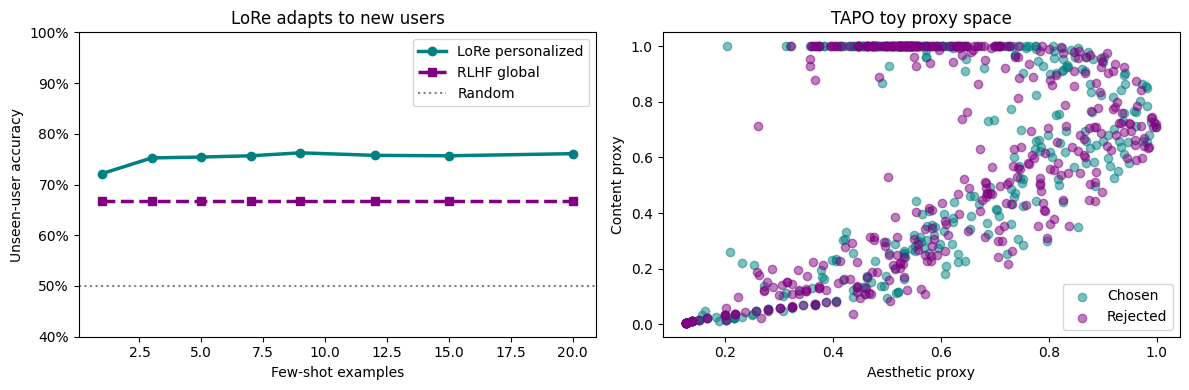

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))  # creates the final two-panel figure

ax[0].plot(shot_counts, lore_curve, 'o-', color='teal', lw=2.5, label='LoRe personalized')  # plots personalized LoRe
ax[0].plot(shot_counts, rlhf_curve, 's--', color='purple', lw=2.5, label='RLHF global')  # plots flat RLHF baseline
ax[0].axhline(0.5, color='gray', linestyle=':', label='Random')  # random guessing baseline
ax[0].set_ylim(0.4, 1.0)  # keeps accuracy scale readable
ax[0].set_xlabel('Few-shot examples')
ax[0].set_ylabel('Unseen-user accuracy')
ax[0].set_title('LoRe adapts to new users')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax[0].legend()

ax[1].scatter(chosen_aesthetic, chosen_content, alpha=0.5, label='Chosen', color='teal')  # plots chosen response proxies
ax[1].scatter(rejected_aesthetic, rejected_content, alpha=0.5, label='Rejected', color='purple')  # plots rejected response proxies
ax[1].set_xlabel('Aesthetic proxy')
ax[1].set_ylabel('Content proxy')
ax[1].set_title('TAPO toy proxy space')
ax[1].legend()  # shows legend

plt.tight_layout()  # makes spacing cleaner
plt.savefig('fig4_final_summary.png', dpi=120, bbox_inches='tight')  # saves final summary figure
plt.show()  # displays final summary figure

**Interpretation:**

The left plot is the main project result: LoRe uses few-shot examples to personalize for unseen users, while RLHF stays flat.

The right plot supports the TAPO explanation by showing that chosen and rejected responses can be compared in a simple content/style proxy space.


# *#6. Final Interpretation*



RLHF / BT learns one global reward model, so it captures an average preference pattern.

LoRe learns a shared low-rank reward basis with `B_RANK = 5`. For a new user, the basis is frozen and only the user weights are learned from few-shot comparisons.

TAPO is shown as a toy aesthetics-loss extension. It demonstrates the idea of adding an aesthetic preference signal, but it is not reported as real model accuracy.

**Why LoRe beats RLHF here**

The simulated users have different mixtures of preference dimensions. A single global reward averages those differences away. LoRe can reuse the shared basis and adapt the user weights, so it has the right structure for personalization.

The personalization-sensitive test makes this especially clear: when the average population is unsure but an individual user has a clear preference, LoRe has a large advantage over global RLHF.
